In [1]:
import pandas as pd
features = pd.read_csv('mondrian-painting-features.csv')
features

,painting_id,feature,x,y,width,height,color,rgb
0,b104,rect,0,0,146,13,white,#ced2ca
1,b104,rect,151,0,576,13,gray,#a4a7a7
2,b104,rect,732,0,278,129,gray,#c8c9c7
3,b104,rect,0,18,146,468,white,#cfd0ce
4,b104,rect,151,18,107,111,black,#151d16
...,...,...,...,...,...,...,...,...
3199,b296,v-line,620,0,19,825,black,#000000
3200,b296,v-line,49,508,19,79,black,#000000
3201,b296,h-line,0,268,711,19,black,#000000
3202,b296,h-line,0,489,711,19,black,#000000


In [3]:
features.query('painting_id == "b104"')

,painting_id,feature,x,y,width,height,color,rgb
0,b104,rect,0,0,146,13,white,#ced2ca
1,b104,rect,151,0,576,13,gray,#a4a7a7
2,b104,rect,732,0,278,129,gray,#c8c9c7
3,b104,rect,0,18,146,468,white,#cfd0ce
4,b104,rect,151,18,107,111,black,#151d16
5,b104,rect,263,18,464,111,blue,#233c55
6,b104,rect,151,134,380,143,gray,#abafaf
7,b104,rect,536,134,191,143,red,#b93e0b
8,b104,rect,732,134,212,143,black,#111712
9,b104,rect,949,134,61,143,blue,#233c55


In [4]:
painting_info = pd.read_csv('mondrian-painting-info.csv')
painting_info

,painting_id,year,title,width,height
0,b104,1920,No. VI,1010,1007
1,b105,1920,Composition A,918,900
2,b106,1920,Composition B,575,677
3,b107,1920,Composition C,610,603
4,b108,1920,Composition I,646,750
...,...,...,...,...,...
131,b292,1939,Composition no. 1,1023,1052
132,b293,1939,"Composition of red, blue and white: II",330,435
133,b294,1939,Trafalgar Square,1200,1452
134,b295,1939,Composition no. 8,681,752


In [ ]:
# Turning data into pictures raw code
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

features = pd.read_csv('mondrian-painting-features.csv')
def draw_mondrian( painting_id ):
    rects = features.query('painting_id == @painting_id')
    total_width = rects.eval("x + width").max()
    total_height = rects.eval("y + height").max()

    fig, ax = plt.subplots()

    for (idx, row) in rects.iterrows():
        x, y, w, h, rgb = row[['x','y','width','height', 'rgb']]
        patch = mpatches.Rectangle((x, y), w, h, facecolor=rgb)
        ax.add_patch(patch)
    
    ax.axis([0, total_width, 0, total_height])
    ax.set_aspect('equal')
    ax.axis('off')
    fig.text(0.5, 0.01, painting_id, ha="center", fontsize=14)
    fig.show()

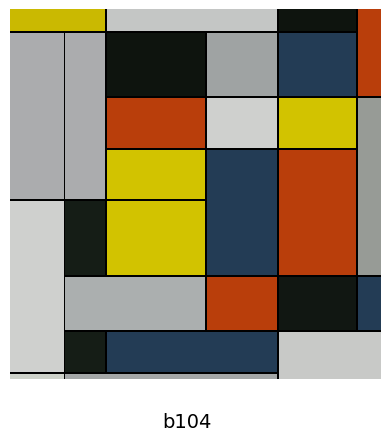

In [ ]:
# Turning data into pictures with painting_id

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

features = pd.read_csv('mondrian-painting-features.csv')
def draw_mondrian( painting_id ):
    rects = features.query('painting_id == @painting_id')
    total_width = rects.eval("x + width").max()
    total_height = rects.eval("y + height").max()

    fig, ax = plt.subplots()

    for (idx, row) in rects.iterrows():
        x, y, w, h, rgb = row[['x','y','width','height', 'rgb']]
        patch = mpatches.Rectangle((x, y), w, h, facecolor=rgb)
        ax.add_patch(patch)
    
    ax.axis([0, total_width, 0, total_height])
    ax.set_aspect('equal')
    ax.axis('off')
    fig.text(0.5, 0.01, painting_id, ha="center", fontsize=14)
    plt.show()

draw_mondrian('b104')

In [5]:
# Features dataframe
features

,painting_id,feature,x,y,width,height,color,rgb
0,b104,rect,0,0,146,13,white,#ced2ca
1,b104,rect,151,0,576,13,gray,#a4a7a7
2,b104,rect,732,0,278,129,gray,#c8c9c7
3,b104,rect,0,18,146,468,white,#cfd0ce
4,b104,rect,151,18,107,111,black,#151d16
...,...,...,...,...,...,...,...,...
3199,b296,v-line,620,0,19,825,black,#000000
3200,b296,v-line,49,508,19,79,black,#000000
3201,b296,h-line,0,268,711,19,black,#000000
3202,b296,h-line,0,489,711,19,black,#000000


In [8]:
# Use groupby to count the number of features
sizes = features.groupby('painting_id').size()
sizes

painting_id
b104    41
b105    42
b106    41
b107    44
b108    44
        ..
b292    31
b293    26
b294    62
b295    47
b296    49
Length: 136, dtype: int64

In [9]:
# Turn the above series into a dataframe usig reset_index
complexity_df = sizes.reset_index(name='complexity')
complexity_df

,painting_id,complexity
0,b104,41
1,b105,42
2,b106,41
3,b107,44
4,b108,44
...,...,...
131,b292,31
132,b293,26
133,b294,62
134,b295,47


In [ ]:
painting_info = pd.read_csv('mondrian-painting-info.csv')
painting_info

,painting_id,year,title,width,height
0,b104,1920,No. VI,1010,1007
1,b105,1920,Composition A,918,900
2,b106,1920,Composition B,575,677
3,b107,1920,Composition C,610,603
4,b108,1920,Composition I,646,750
...,...,...,...,...,...
131,b292,1939,Composition no. 1,1023,1052
132,b293,1939,"Composition of red, blue and white: II",330,435
133,b294,1939,Trafalgar Square,1200,1452
134,b295,1939,Composition no. 8,681,752


In [26]:
# Merging data from painting_info with complexity_df
painting_info = painting_info.merge(complexity_df, on='painting_id', how='left')
painting_info

,painting_id,year,title,width,height,complexity
0,b104,1920,No. VI,1010,1007,41
1,b105,1920,Composition A,918,900,42
2,b106,1920,Composition B,575,677,41
3,b107,1920,Composition C,610,603,44
4,b108,1920,Composition I,646,750,44
...,...,...,...,...,...,...
131,b292,1939,Composition no. 1,1023,1052,31
132,b293,1939,"Composition of red, blue and white: II",330,435,26
133,b294,1939,Trafalgar Square,1200,1452,62
134,b295,1939,Composition no. 8,681,752,47


In [ ]:
# Deleting excess complexity columns
painting_info = painting_info.drop(columns=['complexity_x', 'complexity_y', 'complexity'])

In [ ]:
# Listing column in merged data
painting_info.columns

Index(['painting_id', 'year', 'title', 'width', 'height'], dtype='object')

Text(0, 0.5, 'Complexity')

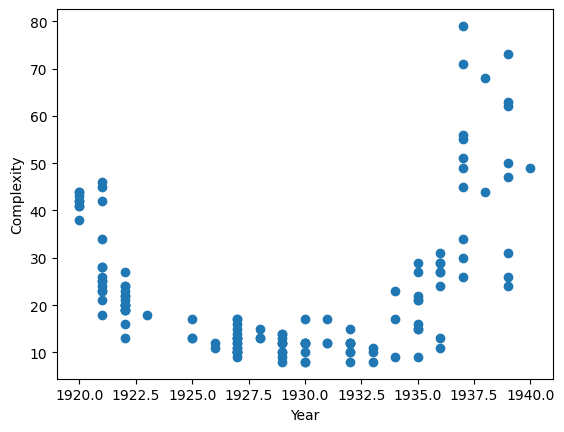

In [28]:
# Plotting complexity over time
import matplotlib.pyplot as plt

plt.scatter(painting_info['year'], painting_info['complexity'])
plt.xlabel('Year')
plt.ylabel('Complexity')

In [29]:
fp26_features = pd.read_csv('fp26-features.csv')
fp26_features

,painting_id,feature,x,y,width,height,color,rgb
0,fp26,rect,0,0,34,92,white,#fafafa
1,fp26,rect,41,0,267,22,white,#f9f9f9
2,fp26,rect,317,0,309,22,white,#fafafa
3,fp26,rect,634,0,38,261,white,#fafafa
4,fp26,rect,680,0,32,261,yellow,#fcf202
5,fp26,rect,41,30,267,62,blue,#2b529d
6,fp26,rect,317,30,109,62,white,#fafafa
7,fp26,rect,433,30,193,62,blue,#2c529d
8,fp26,rect,0,100,34,236,black,#020202
9,fp26,rect,41,100,81,236,white,#fbfbfb


Text(0, 0.5, 'Complexity')

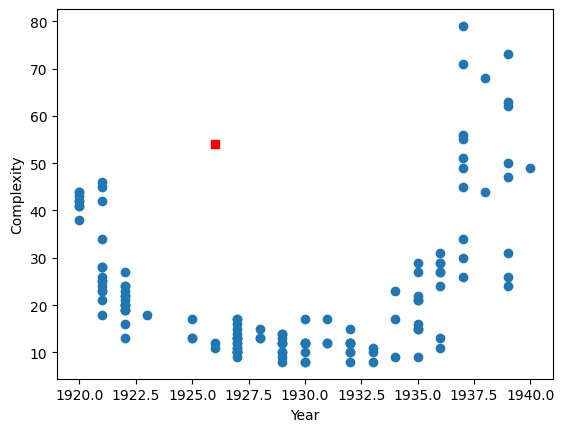

In [30]:
# Add a datapoint to the previous scattered plot

plt.scatter(painting_info['year'], painting_info['complexity'])
plt.scatter(x=1926, y=54, color='red', marker='s')
plt.xlabel('Year')
plt.ylabel('Complexity')